# Il risveglio del neurone

*Siamo il team di ingegneria di **WristMind**, una startup che vuole costruire un braccialetto intelligente capace di riconoscere cosa stai facendo - cammini, corri, sei seduto, stai dormendo - direttamente sul chip al polso, senza connessione internet.*

**La sfida**

*Il reparto hardware ci ha consegnato un dataset: i dati dei sensori di 30 volontari che indossavano uno smartphone al polso mentre svolgevano sei attività diverse. Il capo progetto ci ha posto un vincolo preciso: il modello finale deve girare su un microcontrollore grande come un'unghia, con pochi kilobyte di memoria. Niente cloud, niente server. Tutta l'intelligenza deve stare nel chip. Tutto comincia da qui: da un singolo neurone artificiale.*

## I dati del sensore

I dati che useremo vengono da un esperimento reale condotto all'Università degli Studi di Genova: 30 persone hanno indossato uno smartphone al polso mentre svolgevano sei attività diverse. I sensori — un **accelerometro** e un **giroscopio** — registravano accelerazione e velocità angolare 50 volte al secondo. Da ogni finestra di 2 secondi di segnale sono state poi estratte 561 misure statistiche (media, varianza, energia delle frequenze, ecc.).

Ogni riga del dataset è quindi una "fotografia" di due secondi di attività:

| Codice | Attività |
|--------|----------|
| 1 | Camminare in piano |
| 2 | Salire le scale |
| 3 | Scendere le scale |
| 4 | Seduto |
| 5 | In piedi |
| 6 | Sdraiato |

Questo dataset è uno dei più citati nella letteratura scientifica sull'**Internet of Things** (IoT) e sul riconoscimento di attività umane. Il formato — molte feature estratte da segnali grezzi — è identico a quello che si incontra nella pratica industriale.

In [1]:
# Librerie standard per il calcolo numerico e la visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# sklearn: per caricare il dataset, dividere train/test e normalizzare
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow/Keras: la libreria che useremo per costruire le reti neurali
import tensorflow as tf
from tensorflow import keras

# Fissiamo i seed per avere risultati riproducibili
np.random.seed(42)
tf.random.set_seed(42)

print("Librerie caricate.")
print(f"TensorFlow versione: {tf.__version__}")

Librerie caricate.
TensorFlow versione: 2.16.2


Scarichiamo il dataset dalla piattaforma **OpenML**, un archivio pubblico di dataset scientifici. La prima volta ci vorrà circa un minuto; le volte successive i dati saranno in cache locale e il caricamento sarà istantaneo.

In [2]:
# Carichiamo il dataset UCI HAR (Human Activity Recognition)
# data_id=1478 identifica univocamente questo dataset su OpenML
print("Carico il dataset HAR (potrebbe richiedere qualche secondo)...")
har = fetch_openml(data_id=1478, as_frame=True, parser='auto')

# X: matrice 10299 x 561 con le feature estratte dai sensori
# y: etichette numeriche 1..6 che indicano l'attivita' svolta
X = har.data.astype(np.float32)
y = har.target.astype(int)

# Dizionario per leggere le etichette in modo umano
nomi_attivita = {
    1: "Camminare",
    2: "Salire scale",
    3: "Scendere scale",
    4: "Seduto",
    5: "In piedi",
    6: "Sdraiato"
}

print(f"\nDimensioni: {X.shape[0]} campioni, {X.shape[1]} feature")
print("\nDistribuzione delle attivita':")
for classe, nome in nomi_attivita.items():
    n = (y == classe).sum()
    print(f"  {classe} - {nome:20s}: {n} campioni")

Carico il dataset HAR (potrebbe richiedere qualche secondo)...

Dimensioni: 10299 campioni, 561 feature

Distribuzione delle attivita':
  1 - Camminare           : 1722 campioni
  2 - Salire scale        : 1544 campioni
  3 - Scendere scale      : 1406 campioni
  4 - Seduto              : 1777 campioni
  5 - In piedi            : 1906 campioni
  6 - Sdraiato            : 1944 campioni


Come abbiamo imparato nella lezione 2, prima di costruire qualsiasi modello dobbiamo **separare i dati di addestramento da quelli di test**. Useremo il 25% dei dati come test set, messo da parte fin dall'inizio, per valutare onestamente i nostri modelli alla fine.

Inoltre, le 561 feature hanno scale molto diverse tra loro. Ricordate il problema che abbiamo incontrato nella lezione 2 quando abbiamo provato a usare più feature con scale diverse? La discesa del gradiente "impazziva". Per evitarlo, normalizziamo con la **StandardScaler**: trasforma ogni feature sottraendo la media e dividendo per la deviazione standard, così tutte le feature avranno media 0 e deviazione standard 1.

In [3]:
# Dividiamo train e test (75% / 25%), mantenendo la proporzione delle classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Normalizziamo le feature con StandardScaler
# ATTENZIONE: fit_transform sul training, solo transform sul test
# (le statistiche di normalizzazione si calcolano SOLO sui dati di training)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set: {X_train_sc.shape[0]} campioni")
print(f"Test set:     {X_test_sc.shape[0]} campioni")
print(f"Feature per campione: {X_train_sc.shape[1]}")

Training set: 7724 campioni
Test set:     2575 campioni
Feature per campione: 561


## Dal neurone biologico a quello artificiale

Prenditi un momento: il tuo cervello sta elaborando queste parole. Ogni lettera è percepita da milioni di fotorecettori nella retina, che inviano segnali elettrici attraverso catene di **neuroni**, ciascuno dei quali riceve tanti segnali in ingresso, li combina, e se la somma è abbastanza grande si **attiva** e manda un segnale ai neuroni successivi.

Nel 1943 McCulloch e Pitts proposero un modello matematico che imita questo meccanismo. Nel 1958 Frank Rosenblatt lo implementò nelle prime macchine: il **percettrone**.

L'idea è semplice:
- il neurone ha $p$ **ingressi** $x_1, x_2, \dots, x_p$ (nel nostro caso, 561 misure dei sensori)
- ogni ingresso è moltiplicato per un **peso** $w_j$ (quanto quell'ingresso conta)
- si sommano tutti i contributi e si aggiunge un termine costante $b$ (**bias**)
- il risultato viene passato attraverso una **funzione di attivazione** $\sigma$, che "decide" se il neurone si attiva o no

Il percettrone introduce qualcosa di nuovo rispetto ai modelli lineari visti nella lezione 1: la funzione di attivazione può essere **non lineare**, e questa è la vera chiave di volta.

## Il percettrone: formula matematica

Formalmente, l'uscita di un singolo neurone è:

$$\hat{y} = \sigma\!\left(\sum_{j=1}^{p} w_j \, x_j + b\right) = \sigma(\mathbf{w} \cdot \mathbf{x} + b)$$

dove:
- $\mathbf{x} = (x_1, \dots, x_p)$ è il vettore degli ingressi (le feature del sensore)
- $\mathbf{w} = (w_1, \dots, w_p)$ sono i **pesi** da imparare
- $b$ è il **bias** (intercetta), anch'esso da imparare
- $\sigma$ è la **funzione di attivazione**

Notate che $\mathbf{w} \cdot \mathbf{x} + b$ è **identica** alla formula del classificatore lineare (lezione 1) e del regressore lineare (lezione 2). La novità è $\sigma$.

**Perché serve la funzione di attivazione?**

Senza $\sigma$ (o con $\sigma$ lineare), il percettrone è esattamente un modello lineare: può solo tracciare iperpiani come frontiera di decisione. Con $\sigma$ non lineare, i percettroni impilati in strati possono rappresentare **qualsiasi funzione continua** — come vedremo nel prossimo notebook.

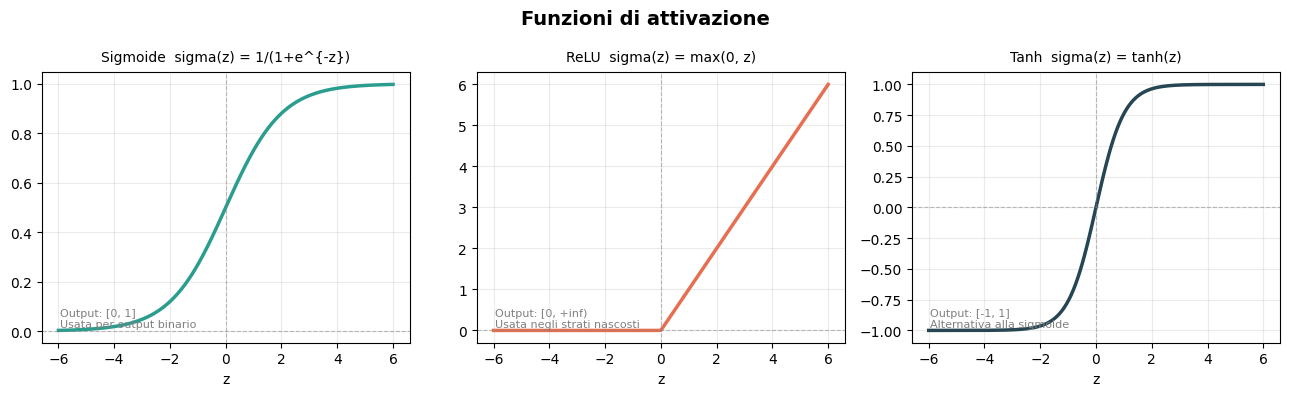

In [4]:
# Visualizziamo le principali funzioni di attivazione
z = np.linspace(-6, 6, 300)

# Sigmoide: schiaccia l'uscita tra 0 e 1 (usata per classificazione binaria)
def sigmoid(z): return 1 / (1 + np.exp(-z))

# ReLU (Rectified Linear Unit): zero se negativo, identita' se positivo
def relu(z): return np.maximum(0, z)

# Tangente iperbolica: simile alla sigmoide ma tra -1 e 1
def tanh_fn(z): return np.tanh(z)

fig, assi = plt.subplots(1, 3, figsize=(13, 4))

config = [
    ("Sigmoide  sigma(z) = 1/(1+e^{-z})", sigmoid,  "#2a9d8f", "Output: [0, 1]\nUsata per output binario"),
    ("ReLU  sigma(z) = max(0, z)",         relu,     "#e76f51", "Output: [0, +inf)\nUsata negli strati nascosti"),
    ("Tanh  sigma(z) = tanh(z)",           tanh_fn,  "#264653", "Output: [-1, 1]\nAlternativa alla sigmoide"),
]

for asse, (titolo, fn, colore, nota) in zip(assi, config):
    asse.plot(z, fn(z), color=colore, linewidth=2.5)
    asse.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    asse.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    asse.set_title(titolo, fontsize=10, pad=8)
    asse.set_xlabel("z")
    asse.text(0.05, 0.05, nota, transform=asse.transAxes,
              fontsize=8, color="gray", verticalalignment='bottom')
    asse.grid(True, alpha=0.25)

plt.suptitle("Funzioni di attivazione", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Primo problema: classificazione binaria

Prima di affrontare tutte e sei le attività, cominciamo con un problema più semplice: **distinguere tra riposo e movimento**.

Raggruppiamo le sei attività in due categorie:
- **Riposo** (classe 0): seduto, in piedi, sdraiato — il braccialetto è fermo
- **Movimento** (classe 1): camminare, salire, scendere le scale — c'è accelerazione

Questo è un **problema di classificazione binaria**: il nostro neurone deve imparare a rispondere 0 o 1. Useremo la funzione di attivazione **sigmoide** in uscita, così il neurone restituirà un numero tra 0 e 1 che interpretiamo come *probabilità di essere in movimento*.

In [5]:
# Trasformiamo il target in binario:
# - classi 1, 2, 3 (camminare, salire, scendere) --> 1 = movimento
# - classi 4, 5, 6 (seduto, in piedi, sdraiato)  --> 0 = riposo
y_train_bin = (y_train <= 3).astype(int)
y_test_bin  = (y_test  <= 3).astype(int)

print("Training set:")
print(f"  Movimento (1): {y_train_bin.sum()} campioni")
print(f"  Riposo    (0): {(y_train_bin == 0).sum()} campioni")
print(f"\nTest set:")
print(f"  Movimento (1): {y_test_bin.sum()} campioni")
print(f"  Riposo    (0): {(y_test_bin == 0).sum()} campioni")

Training set:
  Movimento (1): 3504 campioni
  Riposo    (0): 4220 campioni

Test set:
  Movimento (1): 1168 campioni
  Riposo    (0): 1407 campioni


## Costruiamo il nostro primo neurone con Keras

**Keras** è la libreria standard per costruire reti neurali in Python. Con poche righe di codice possiamo descrivere l'architettura della rete, specificare come addestrarla e poi lasciarla imparare dai dati.

In Keras, un modello si costruisce come una sequenza di **strati** (`layers`). Un singolo neurone è lo strato `Dense` (completamente connesso) con una sola unità. Dobbiamo specificare:
- **Quante unità** ha lo strato (1, perché vogliamo un solo neurone)
- **La funzione di attivazione** (`sigmoid` per output binario)
- **La forma dell'input** (561 feature per campione)

In [6]:
# Costruiamo il modello: un unico neurone con attivazione sigmoide
# Sequential = "strati in sequenza", come vagoni di un treno
modello_neurone = keras.Sequential([
    keras.layers.Dense(
        units=1,                              # un solo neurone in uscita
        activation='sigmoid',                 # sigmoide: output tra 0 e 1
        input_shape=(X_train_sc.shape[1],)   # 561 feature in ingresso
    )
], name="singolo_neurone")

# Compiliamo: specifichiamo ottimizzatore, funzione costo e metriche
# adam    = versione avanzata della discesa del gradiente (vista nella lezione 2)
# binary_crossentropy = la funzione costo standard per classificazione binaria
# accuracy = la metrica che mostriamo durante il training
modello_neurone.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Riepilogo del modello: mostra strati, dimensioni e numero di parametri
modello_neurone.summary()

2026-05-06 18:17:03.584358: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-06 18:17:03.584389: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-06 18:17:03.584392: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-05-06 18:17:03.584437: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-06 18:17:03.584452: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "singolo_neurone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562 (2.20 KB)

 Trainable params: 562 (2.20 KB)

 Non-trainable params: 0 (0.00 B)

Il riepilogo mostra **562 parametri**: 561 pesi (uno per feature) più 1 bias. Sono esattamente i $w_j$ e $b$ della formula del percettrone.

Come funziona il training? Esattamente come nella lezione 2: la **discesa del gradiente** calcola quanto ogni parametro contribuisce all'errore e li aggiusta un po' alla volta per ridurlo. Keras lo fa automaticamente per noi.

Un **epoch** è una passata completa su tutto il training set. Il parametro `validation_split=0.2` riserva il 20% dei dati di training per monitorare il modello durante l'apprendimento, senza toccare il test set.

In [7]:
# Addestriamo il modello
# epochs=30: 30 passate complete sul training set
# validation_split=0.2: 20% del training usato per monitorare il progresso
# verbose=0: non stampa nulla riga per riga (usiamo il grafico sotto)
storia = modello_neurone.fit(
    X_train_sc, y_train_bin,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

# Valutiamo le prestazioni sul test set (dati che il modello non ha MAI visto)
loss_test, acc_test = modello_neurone.evaluate(X_test_sc, y_test_bin, verbose=0)
print(f"Accuratezza sul test set: {acc_test:.1%}")

2026-05-06 18:17:04.119729: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Accuratezza sul test set: 100.0%


Le **curve di apprendimento** (o *learning curves*) sono uno strumento fondamentale: mostrano come accuratezza e funzione costo evolvono durante il training. Cerchiamo due cose:
1. Le curve scendono/salgono nella direzione giusta → il modello sta imparando
2. Training e validation sono vicini → il modello generalizza bene (non sta memorizzando)

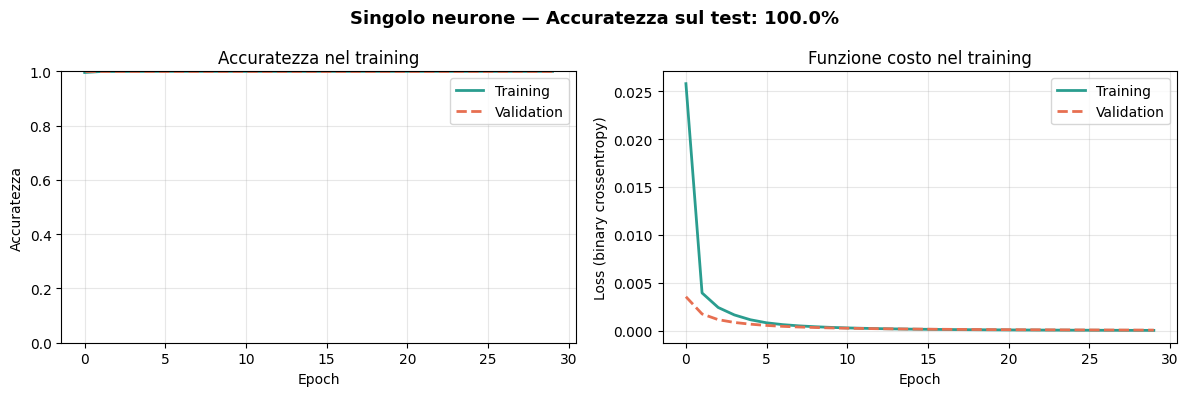

In [8]:
fig, assi = plt.subplots(1, 2, figsize=(12, 4))

# Curva dell'accuratezza: vogliamo che salga e che training ~ validation
assi[0].plot(storia.history['accuracy'],
             label='Training', color='#2a9d8f', linewidth=2)
assi[0].plot(storia.history['val_accuracy'],
             label='Validation', color='#e76f51', linewidth=2, linestyle='--')
assi[0].set_title('Accuratezza nel training')
assi[0].set_xlabel('Epoch')
assi[0].set_ylabel('Accuratezza')
assi[0].legend()
assi[0].grid(True, alpha=0.3)
assi[0].set_ylim([0, 1])

# Curva della loss: vogliamo che scenda e che training ~ validation
assi[1].plot(storia.history['loss'],
             label='Training', color='#2a9d8f', linewidth=2)
assi[1].plot(storia.history['val_loss'],
             label='Validation', color='#e76f51', linewidth=2, linestyle='--')
assi[1].set_title('Funzione costo nel training')
assi[1].set_xlabel('Epoch')
assi[1].set_ylabel('Loss (binary crossentropy)')
assi[1].legend()
assi[1].grid(True, alpha=0.3)

plt.suptitle(f'Singolo neurone — Accuratezza sul test: {acc_test:.1%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretiamo i risultati

Il singolo neurone distingue riposo da movimento con un'accuratezza molto alta. Questo non è casuale: il problema binario "fermo vs. in movimento" è quasi **linearmente separabile** — quando cammini, l'accelerometro produce segnali molto diversi rispetto a quando sei sdraiato. Una sola frontiera lineare riesce già a separare bene le due categorie.

Ma c'è un limite fondamentale di questo approccio: **un singolo neurone può solo tracciare una frontiera lineare** (un iperpiano in 561 dimensioni). Se le classi non sono linearmente separabili — come nel caso delle sei attività — un neurone solo non basterà.

Osserviamo questo limite con un esperimento diretto: proviamo ad addestrare lo stesso neurone sul problema **multiclasse** (6 classi). Cosa succede?

In [9]:
# Un singolo strato lineare con 6 uscite: e' il limite del modello lineare
# Usiamo softmax: trasforma 6 numeri in 6 probabilita' che sommano a 1
modello_lineare_multi = keras.Sequential([
    keras.layers.Dense(6, activation='softmax', input_shape=(X_train_sc.shape[1],))
], name="lineare_multiclasse")

modello_lineare_multi.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Convertiamo le etichette in indici 0-based (keras si aspetta 0..N-1)
y_train_0 = y_train - 1
y_test_0  = y_test  - 1

# Training breve per vedere le prestazioni massime raggiungibili
storia_lin = modello_lineare_multi.fit(
    X_train_sc, y_train_0,
    epochs=30, validation_split=0.2, verbose=0
)
_, acc_lin = modello_lineare_multi.evaluate(X_test_sc, y_test_0, verbose=0)
print(f"Modello lineare (6 classi) — Accuratezza test: {acc_lin:.1%}")
print(f"Modello binario (2 classi) — Accuratezza test: {acc_test:.1%}")
print("\nCon 6 classi il modello lineare non basta: servono gli strati nascosti!")

Modello lineare (6 classi) — Accuratezza test: 97.7%
Modello binario (2 classi) — Accuratezza test: 100.0%

Con 6 classi il modello lineare non basta: servono gli strati nascosti!


---

> **Cosa abbiamo imparato** — Il percettrone è il mattone fondamentale delle reti neurali. La sua formula — combinazione lineare degli ingressi seguita da una funzione di attivazione — è una generalizzazione dei modelli lineari visti nella lezione 1 e 2. La funzione di attivazione introduce la non-linearità che rende le reti neurali così potenti. Abbiamo costruito e addestrato un singolo neurone con Keras, letto le curve di apprendimento e visto che riesce bene su un problema binario semplice. Tuttavia, un solo neurone (anche con 6 uscite) non è sufficiente per distinguere tra sei attività diverse: le frontiere di decisione che può tracciare sono troppo semplici.

> **Cosa faremo adesso** — Nel prossimo notebook scopriremo come impilare neuroni in più strati successivi per costruire una **rete neurale multi-strato** (Multi-Layer Perceptron). Vedremo come questa architettura più profonda riesce a imparare frontiere di decisione arbitrariamente complesse, e la useremo per classificare tutte e sei le attività del nostro braccialetto WristMind.